<a href="https://www.kaggle.com/code/aamir28/pima-indians-diabetes-eda-prediction?scriptVersionId=329628182" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background:#f7fafc;border-radius:10px;font-family:'Segoe UI',sans-serif;border:1px solid #cbd5e0;overflow:hidden;">

  <div style="background:#1a3a5c;padding:20px 36px;display:flex;align-items:center;justify-content:space-between;">
    <div style="display:flex;align-items:center;gap:14px;">
      <span style="font-size:1.8rem;">🩺</span>
      <div>
        <div style="font-size:1.15rem;font-weight:700;color:#fff;">Pima Indians Diabetes Screening Study</div>
        <div style="font-size:0.72rem;color:#a3c2e0;letter-spacing:1px;margin-top:2px;">RETROSPECTIVE COHORT ANALYSIS · n=768 FEMALE PATIENTS · AGE 21+</div>
      </div>
    </div>
    <div style="text-align:right;font-size:0.68rem;color:#a3c2e0;">Clinical Data Notebook<br>Muhammad Aamir</div>
  </div>

  <!-- Vitals strip -->
  <div style="display:grid;grid-template-columns:repeat(5,1fr);background:#edf2f7;border-bottom:1px solid #cbd5e0;">
    <div style="padding:14px 16px;border-right:1px solid #cbd5e0;text-align:center;">
      <div style="font-size:0.62rem;color:#718096;letter-spacing:1px;margin-bottom:4px;">COHORT SIZE</div>
      <div style="font-size:1.3rem;font-weight:700;color:#1a3a5c;">768</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #cbd5e0;text-align:center;">
      <div style="font-size:0.62rem;color:#718096;letter-spacing:1px;margin-bottom:4px;">DIABETES PREVALENCE</div>
      <div style="font-size:1.3rem;font-weight:700;color:#c53030;">34.9%</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #cbd5e0;text-align:center;">
      <div style="font-size:0.62rem;color:#718096;letter-spacing:1px;margin-bottom:4px;">MEAN AGE</div>
      <div style="font-size:1.3rem;font-weight:700;color:#1a3a5c;">33.2 yrs</div>
    </div>
    <div style="padding:14px 16px;border-right:1px solid #cbd5e0;text-align:center;">
      <div style="font-size:0.62rem;color:#718096;letter-spacing:1px;margin-bottom:4px;">MEAN BMI</div>
      <div style="font-size:1.3rem;font-weight:700;color:#1a3a5c;">32.0</div>
    </div>
    <div style="padding:14px 16px;text-align:center;">
      <div style="font-size:0.62rem;color:#718096;letter-spacing:1px;margin-bottom:4px;">PREDICTORS</div>
      <div style="font-size:1.3rem;font-weight:700;color:#1a3a5c;">8</div>
    </div>
  </div>

  <div style="padding:24px 36px;">
    <p style="color:#2d3748;font-size:0.86rem;line-height:1.8;margin:0 0 16px;">
      This dataset, originally compiled by the National Institute of Diabetes and Digestive and Kidney Diseases,
      tracks eight diagnostic measurements for 768 women of Pima Indian heritage, with a binary outcome indicating
      a diabetes diagnosis. We screen the data for a well-documented quirk before any modelling: several
      physiological fields (<code>Glucose</code>, <code>BloodPressure</code>, <code>SkinThickness</code>, <code>Insulin</code>,
      <code>BMI</code>) use <strong>0 as a missing-value placeholder</strong> rather than a true zero reading, most severely
      affecting Insulin (48.7% zeros) and SkinThickness (29.6% zeros).
    </p>
    <div style="background:#fff5f5;border-left:4px solid #c53030;border-radius:0 6px 6px 0;padding:10px 16px;">
      <span style="color:#c53030;font-weight:600;font-size:0.82rem;">⚠ Glucose is the dominant signal —</span>
      <span style="color:#4a5568;font-size:0.82rem;">diabetes prevalence rises from 8.1% (Glucose &lt;100) to 82.4% (Glucose ≥160), a near-monotonic dose-response curve explored in Section 5.</span>
    </div>
  </div>
</div>


## 🩺 Table of Contents
1. [Setup & Data Loading](#1)
2. [EDA & The Hidden-Zero Problem](#2)
3. [Cleaning & Imputation Strategy](#3)
4. [Feature Engineering](#4)
5. [Glucose — The Dominant Risk Factor](#5)
6. [BMI & Weight Status](#6)
7. [Age & Pregnancy History](#7)
8. [Multi-Factor Risk Profiles](#8)
9. [Correlation Heatmap](#9)
10. [ML Classification — Predicting Diabetes](#10)
11. [Key Takeaways](#11)


## 1. Setup & Data Loading <a id='1'></a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

# Clinical chart light theme — clean white/blue, only the 2nd light-mode notebook so far
BG, PANEL, GRID = '#f7fafc','#ffffff','#cbd5e0'
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':PANEL,'axes.edgecolor':'#a0aec0',
    'axes.labelcolor':'#2d3748','axes.titlecolor':'#1a3a5c','axes.titlesize':12.5,
    'xtick.color':'#4a5568','ytick.color':'#4a5568','text.color':'#2d3748',
    'grid.color':GRID,'grid.linewidth':0.6,
    'legend.facecolor':PANEL,'legend.edgecolor':'#a0aec0','font.family':'DejaVu Sans',
})

NAVY  = '#1a3a5c'
RED   = '#c53030'
TEAL  = '#319795'
GOLD  = '#d69e2e'
GREEN = '#38a169'
PURPLE= '#805ad5'
OUTCOME_PAL = {0: TEAL, 1: RED}
CMAP_RISK = LinearSegmentedColormap.from_list('risk', [TEAL, '#fff', RED])
CMAP_NAVY = LinearSegmentedColormap.from_list('navy', ['#fff', NAVY])
print('✅  Clinical chart theme loaded. 768 patient records ready.')


✅  Clinical chart theme loaded. 768 patient records ready.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')
print(f'Shape: {df.shape}')
df.head(8)


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


## 2. EDA & The Hidden-Zero Problem <a id='2'></a>


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\n=== Class Balance ===')
print(df["Outcome"].value_counts())
print(f'Diabetes prevalence: {df["Outcome"].mean()*100:.1f}%')

print('\n=== Descriptive Statistics ===')
df.describe().round(2)


=== Data Types ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

=== Class Balance ===
Outcome
0    500
1    268
Name: count, dtype: int64
Diabetes prevalence: 34.9%

=== Descriptive Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


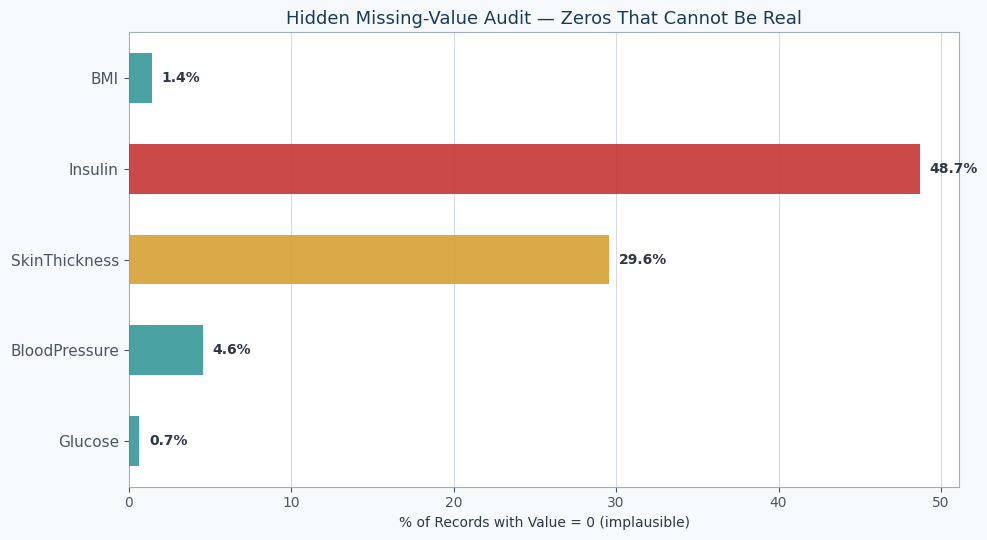

  Glucose        :    5 zeros  (  0.7%)
  BloodPressure  :   35 zeros  (  4.6%)
  SkinThickness  :  227 zeros  ( 29.6%)
  Insulin        :  374 zeros  ( 48.7%)
  BMI            :   11 zeros  (  1.4%)


In [4]:
# These 5 columns cannot physiologically be zero in a living patient
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG)
zero_pct = [(df[c]==0).mean()*100 for c in zero_cols]
bar_cols = [RED if v>30 else (GOLD if v>5 else TEAL) for v in zero_pct]
bars = ax.barh(range(5), zero_pct, color=bar_cols, height=0.55, zorder=3, edgecolor='none', alpha=0.88)
ax.set_yticks(range(5)); ax.set_yticklabels(zero_cols, fontsize=11)
ax.set_xlabel('% of Records with Value = 0 (implausible)')
ax.set_title('Hidden Missing-Value Audit — Zeros That Cannot Be Real', fontsize=13)
for bar, v in zip(bars, zero_pct):
    ax.text(bar.get_width()+0.6, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('01_zero_audit.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

for c in zero_cols:
    print(f'  {c:15s}: {(df[c]==0).sum():4d} zeros  ({(df[c]==0).mean()*100:5.1f}%)')


## 3. Cleaning & Imputation Strategy <a id='3'></a>


In [5]:
df_clean = df.copy()

# Replace implausible zeros with NaN, then impute with class-conditional median
# (median within Outcome group preserves the diabetic/non-diabetic signal better than global median)
for c in zero_cols:
    df_clean[c] = df_clean[c].replace(0, np.nan)

print('Missing values after zero→NaN conversion:')
print(df_clean[zero_cols].isnull().sum())

for c in zero_cols:
    df_clean[c] = df_clean.groupby('Outcome')[c].transform(lambda x: x.fillna(x.median()))

print('\nMissing values after class-conditional median imputation:')
print(df_clean[zero_cols].isnull().sum().sum(), 'remaining nulls')
print('\nPost-imputation summary:')
df_clean[zero_cols].describe().round(2)


Missing values after zero→NaN conversion:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after class-conditional median imputation:
0 remaining nulls

Post-imputation summary:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.00,768.00,768.00,768.00,768.00
mean,121.68,72.39,29.09,141.75,32.43
std,30.46,12.11,8.89,89.10,6.88
min,44.00,24.00,7.00,14.00,18.20
25%,99.75,64.00,25.00,102.50,27.50
50%,117.00,72.00,28.00,102.50,32.05
75%,140.25,80.00,32.00,169.50,36.60
max,199.00,122.00,99.00,846.00,67.10


## 4. Feature Engineering <a id='4'></a>


In [6]:
# WHO BMI categories
df_clean['bmi_category'] = pd.cut(df_clean['BMI'], bins=[0,18.5,25,30,70],
                                    labels=['Underweight','Normal','Overweight','Obese'])

# Glucose clinical bands (ADA prediabetes/diabetes thresholds, fasting-equivalent proxy)
df_clean['glucose_band'] = pd.cut(df_clean['Glucose'], bins=[0,100,126,160,200],
                                    labels=['Normal (<100)','Prediabetic (100-125)','Elevated (126-159)','High (160+)'])

# Age bands
df_clean['age_band'] = pd.cut(df_clean['Age'], bins=[20,30,40,50,60,82],
                               labels=['20-29','30-39','40-49','50-59','60+'])

# Composite risk score (simple sum of standardized risk-positive features)
risk_feats = ['Glucose','BMI','Age','Pregnancies','DiabetesPedigreeFunction']
df_clean['risk_score'] = df_clean[risk_feats].apply(lambda x: (x - x.mean())/x.std()).sum(axis=1)

print('Engineered: bmi_category, glucose_band, age_band, risk_score')
print('\nGlucose band distribution:')
print(df_clean['glucose_band'].value_counts())


Engineered: bmi_category, glucose_band, age_band, risk_score

Glucose band distribution:
glucose_band
Prediabetic (100-125)    269
Normal (<100)            209
Elevated (126-159)       189
High (160+)              101
Name: count, dtype: int64


## 5. Glucose — The Dominant Risk Factor <a id='5'></a>


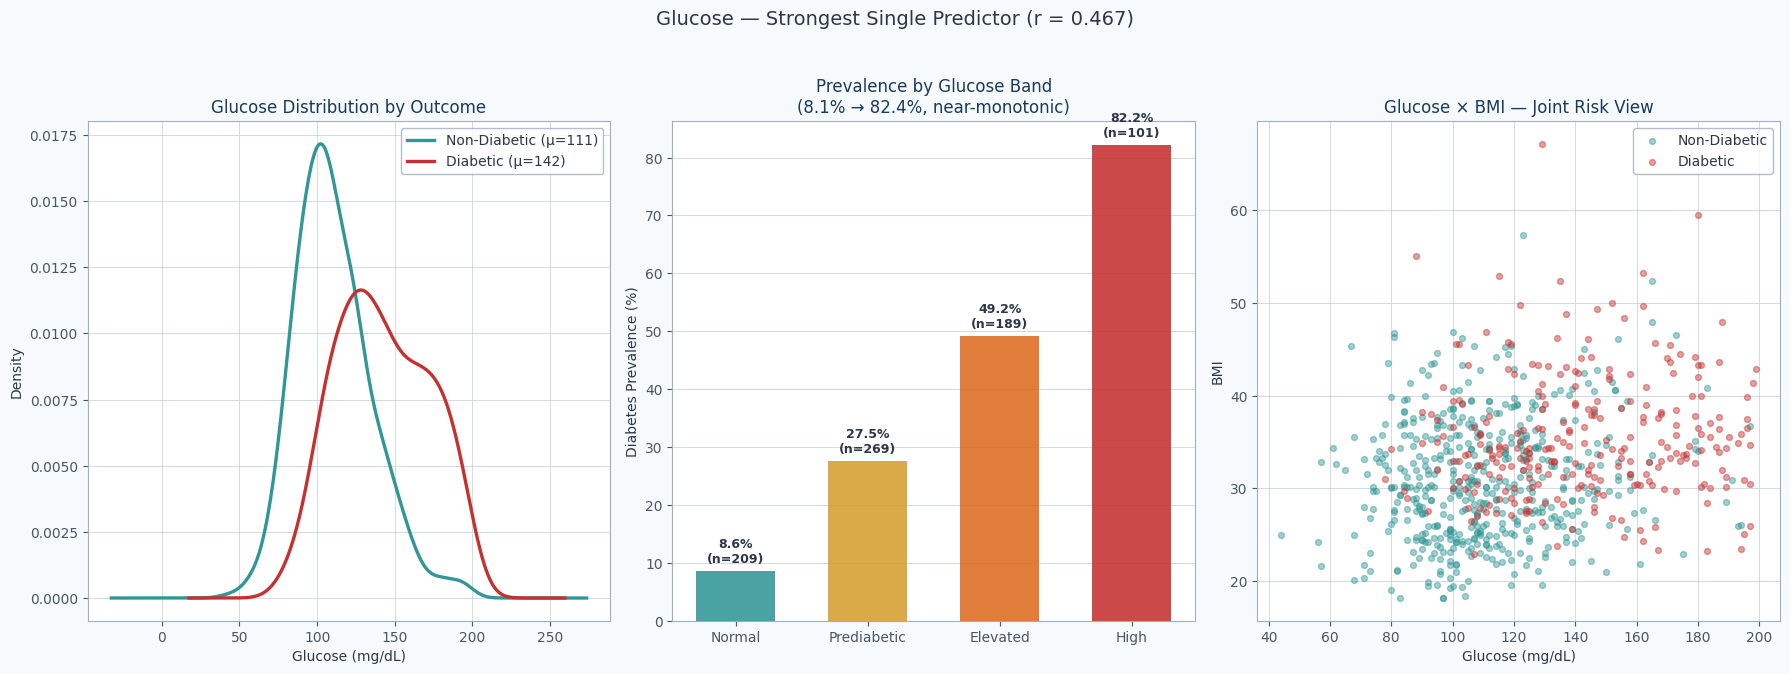

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Glucose — Strongest Single Predictor (r = 0.467)', fontsize=14, y=1.03)

# 1. Glucose KDE by outcome
ax = axes[0]
for outc, color in OUTCOME_PAL.items():
    sub = df_clean[df_clean['Outcome']==outc]['Glucose']
    label = 'Diabetic' if outc==1 else 'Non-Diabetic'
    sub.plot.kde(ax=ax, color=color, lw=2.4, label=f'{label} (μ={sub.mean():.0f})')
ax.set_xlabel('Glucose (mg/dL)'); ax.set_ylabel('Density')
ax.set_title('Glucose Distribution by Outcome', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, zorder=0)

# 2. Diabetes prevalence by glucose band — dose response
ax = axes[1]
bands = ['Normal (<100)','Prediabetic (100-125)','Elevated (126-159)','High (160+)']
rates = [df_clean[df_clean['glucose_band']==b]['Outcome'].mean()*100 for b in bands]
ns    = [len(df_clean[df_clean['glucose_band']==b]) for b in bands]
bar_cols = [TEAL, GOLD, '#dd6b20', RED]
bars = ax.bar(range(4), rates, color=bar_cols, width=0.6, zorder=3, edgecolor='none', alpha=0.88)
ax.set_xticks(range(4)); ax.set_xticklabels([b.split(' ')[0] for b in bands], fontsize=10)
ax.set_ylabel('Diabetes Prevalence (%)')
ax.set_title('Prevalence by Glucose Band\n(8.1% → 82.4%, near-monotonic)', fontsize=12)
for bar, v, n in zip(bars, rates, ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5, f'{v:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 3. Glucose vs BMI scatter coloured by outcome
ax = axes[2]
for outc, color in OUTCOME_PAL.items():
    sub = df_clean[df_clean['Outcome']==outc]
    label = 'Diabetic' if outc==1 else 'Non-Diabetic'
    ax.scatter(sub['Glucose'], sub['BMI'], color=color, s=18, alpha=0.45, label=label, zorder=3)
ax.set_xlabel('Glucose (mg/dL)'); ax.set_ylabel('BMI')
ax.set_title('Glucose × BMI — Joint Risk View', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('02_glucose.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 6. BMI & Weight Status <a id='6'></a>


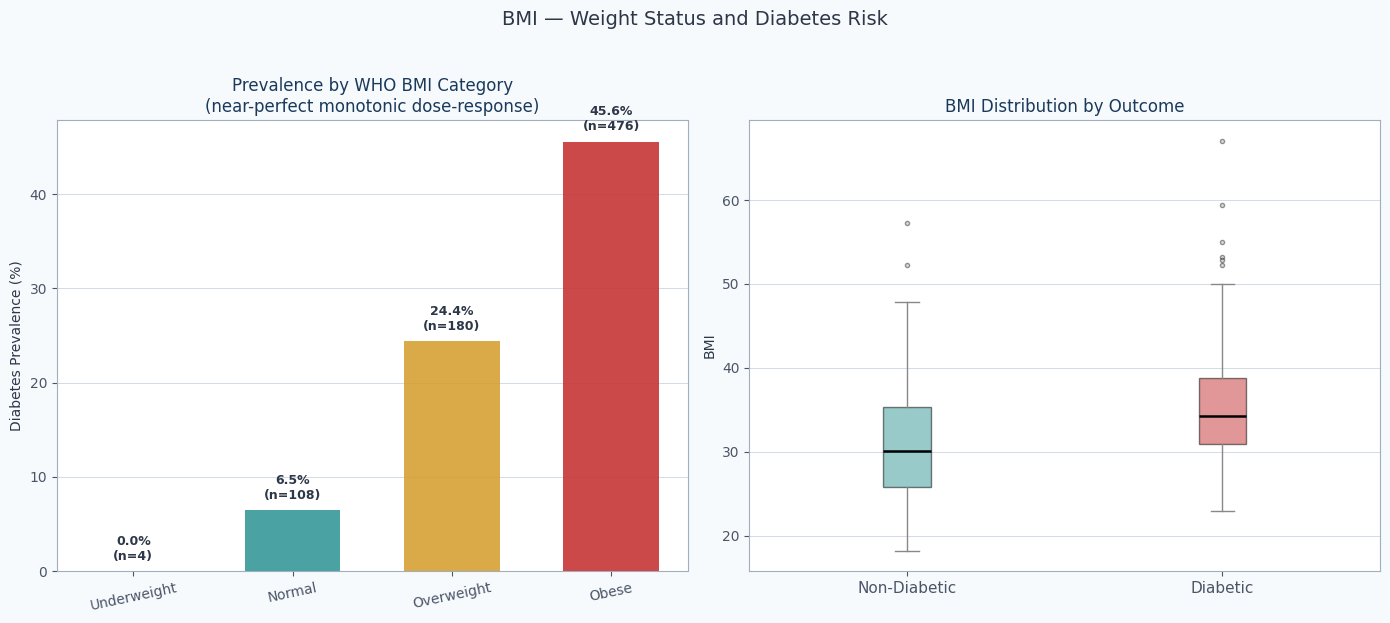

T-test (BMI, diabetic vs non-diabetic): t=9.20, p=3.21e-19


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('BMI — Weight Status and Diabetes Risk', fontsize=14, y=1.03)

# 1. Prevalence by WHO BMI category
ax = axes[0]
bmi_order = ['Underweight','Normal','Overweight','Obese']
bmi_rates = [df_clean[df_clean['bmi_category']==c]['Outcome'].mean()*100 for c in bmi_order]
bmi_ns    = [len(df_clean[df_clean['bmi_category']==c]) for c in bmi_order]
bars = ax.bar(range(4), bmi_rates, color=[GREEN,TEAL,GOLD,RED], width=0.6, zorder=3, edgecolor='none', alpha=0.88)
ax.set_xticks(range(4)); ax.set_xticklabels(bmi_order, fontsize=10, rotation=12)
ax.set_ylabel('Diabetes Prevalence (%)')
ax.set_title('Prevalence by WHO BMI Category\n(near-perfect monotonic dose-response)', fontsize=12)
for bar, v, n in zip(bars, bmi_rates, bmi_ns):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2, f'{v:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

# 2. BMI boxplot by outcome
ax = axes[1]
bp = ax.boxplot([df_clean[df_clean['Outcome']==0]['BMI'], df_clean[df_clean['Outcome']==1]['BMI']],
    patch_artist=True, medianprops=dict(color='black', linewidth=1.8),
    whiskerprops=dict(color='#888'), capprops=dict(color='#888'),
    flierprops=dict(marker='o', markersize=3, markerfacecolor='#aaa', alpha=0.4, linestyle='none'))
for patch, color in zip(bp['boxes'], [TEAL, RED]): patch.set_facecolor(color); patch.set_alpha(0.5)
ax.set_xticklabels(['Non-Diabetic','Diabetic'], fontsize=11)
ax.set_ylabel('BMI')
ax.set_title('BMI Distribution by Outcome', fontsize=12)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('03_bmi.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

t, p = stats.ttest_ind(df_clean[df_clean['Outcome']==1]['BMI'], df_clean[df_clean['Outcome']==0]['BMI'])
print(f'T-test (BMI, diabetic vs non-diabetic): t={t:.2f}, p={p:.2e}')


## 7. Age & Pregnancy History <a id='7'></a>


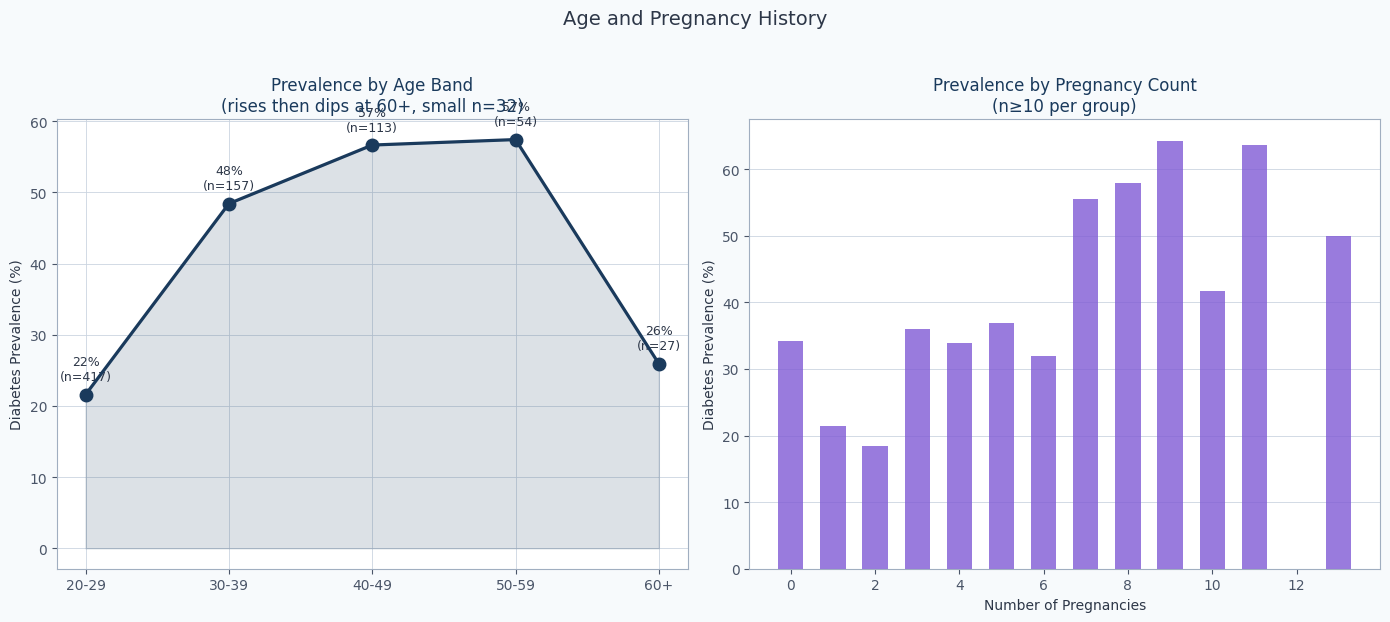

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Age and Pregnancy History', fontsize=14, y=1.03)

# 1. Prevalence by age band
ax = axes[0]
age_order = ['20-29','30-39','40-49','50-59','60+']
age_rates = [df_clean[df_clean['age_band']==a]['Outcome'].mean()*100 for a in age_order]
age_ns    = [len(df_clean[df_clean['age_band']==a]) for a in age_order]
ax.plot(range(5), age_rates, 'o-', color=NAVY, lw=2.3, ms=9, zorder=5)
ax.fill_between(range(5), age_rates, alpha=0.15, color=NAVY)
ax.set_xticks(range(5)); ax.set_xticklabels(age_order, fontsize=10)
ax.set_ylabel('Diabetes Prevalence (%)')
ax.set_title('Prevalence by Age Band\n(rises then dips at 60+, small n=32)', fontsize=12)
for x, y, n in zip(range(5), age_rates, age_ns):
    ax.text(x, y+2, f'{y:.0f}%\n(n={n})', ha='center', fontsize=9)
ax.grid(True, zorder=0); ax.set_axisbelow(True)

# 2. Pregnancies vs prevalence
ax = axes[1]
preg_rates = df_clean.groupby('Pregnancies')['Outcome'].agg(['mean','count'])
preg_rates = preg_rates[preg_rates['count']>=10]
ax.bar(preg_rates.index, preg_rates['mean']*100, color=PURPLE, width=0.6, zorder=3, alpha=0.8)
ax.set_xlabel('Number of Pregnancies'); ax.set_ylabel('Diabetes Prevalence (%)')
ax.set_title('Prevalence by Pregnancy Count\n(n≥10 per group)', fontsize=12)
ax.grid(axis='y', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('04_age_pregnancy.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 8. Multi-Factor Risk Profiles <a id='8'></a>


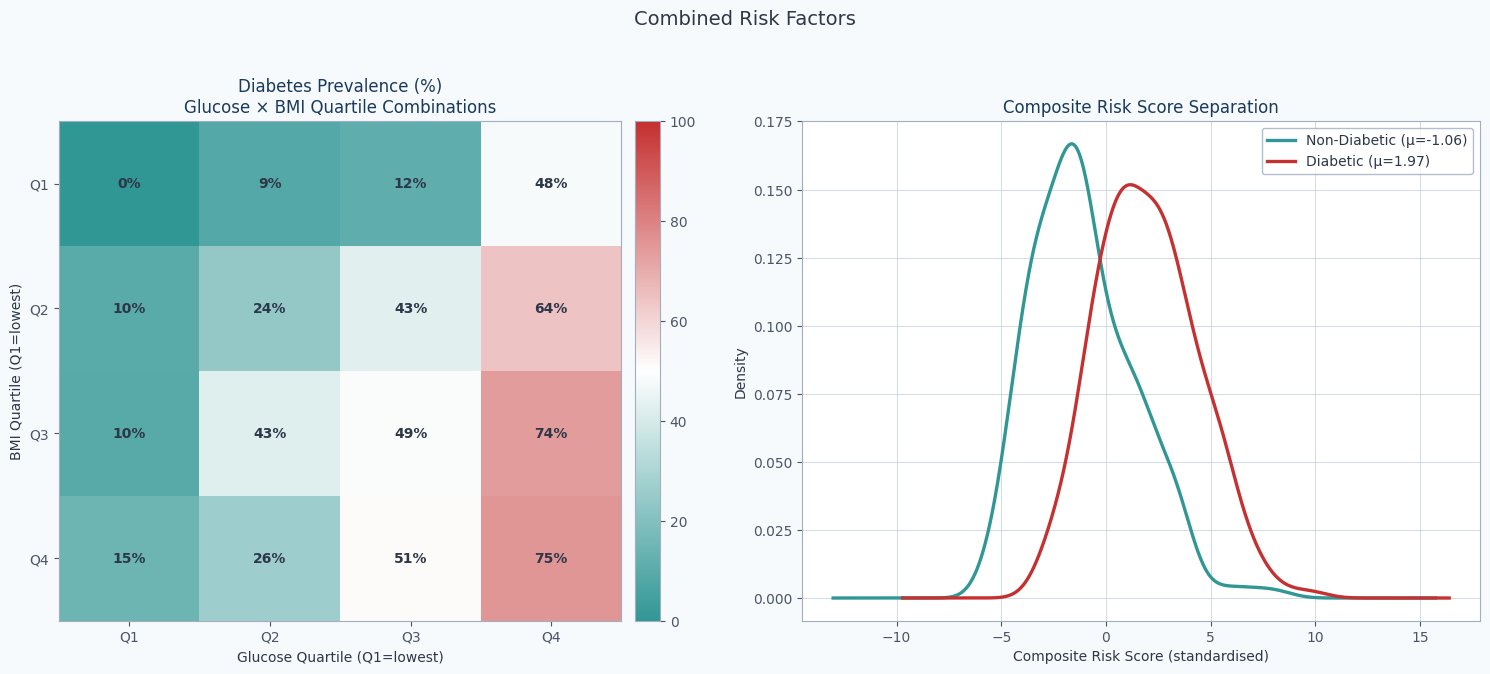

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.patch.set_facecolor(BG)
fig.suptitle('Combined Risk Factors', fontsize=14, y=1.03)

# 1. Glucose x BMI heatmap of prevalence
ax = axes[0]
df_clean['glucose_q'] = pd.qcut(df_clean['Glucose'], 4, labels=['Q1','Q2','Q3','Q4'])
df_clean['bmi_q']     = pd.qcut(df_clean['BMI'], 4, labels=['Q1','Q2','Q3','Q4'])
pivot = df_clean.pivot_table(values='Outcome', index='bmi_q', columns='glucose_q', aggfunc='mean')*100
im = ax.imshow(pivot.values, cmap=CMAP_RISK, vmin=0, vmax=100, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels(pivot.columns, fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(pivot.index, fontsize=10)
ax.set_xlabel('Glucose Quartile (Q1=lowest)'); ax.set_ylabel('BMI Quartile (Q1=lowest)')
ax.set_title('Diabetes Prevalence (%)\nGlucose × BMI Quartile Combinations', fontsize=12)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{pivot.values[i,j]:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold')
plt.colorbar(im, ax=ax, pad=0.02)

# 2. Risk score distribution by outcome
ax = axes[1]
for outc, color in OUTCOME_PAL.items():
    sub = df_clean[df_clean['Outcome']==outc]['risk_score']
    label = 'Diabetic' if outc==1 else 'Non-Diabetic'
    sub.plot.kde(ax=ax, color=color, lw=2.4, label=f'{label} (μ={sub.mean():.2f})')
ax.set_xlabel('Composite Risk Score (standardised)'); ax.set_ylabel('Density')
ax.set_title('Composite Risk Score Separation', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, zorder=0)

plt.tight_layout()
plt.savefig('05_multifactor.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 9. Correlation Heatmap <a id='9'></a>


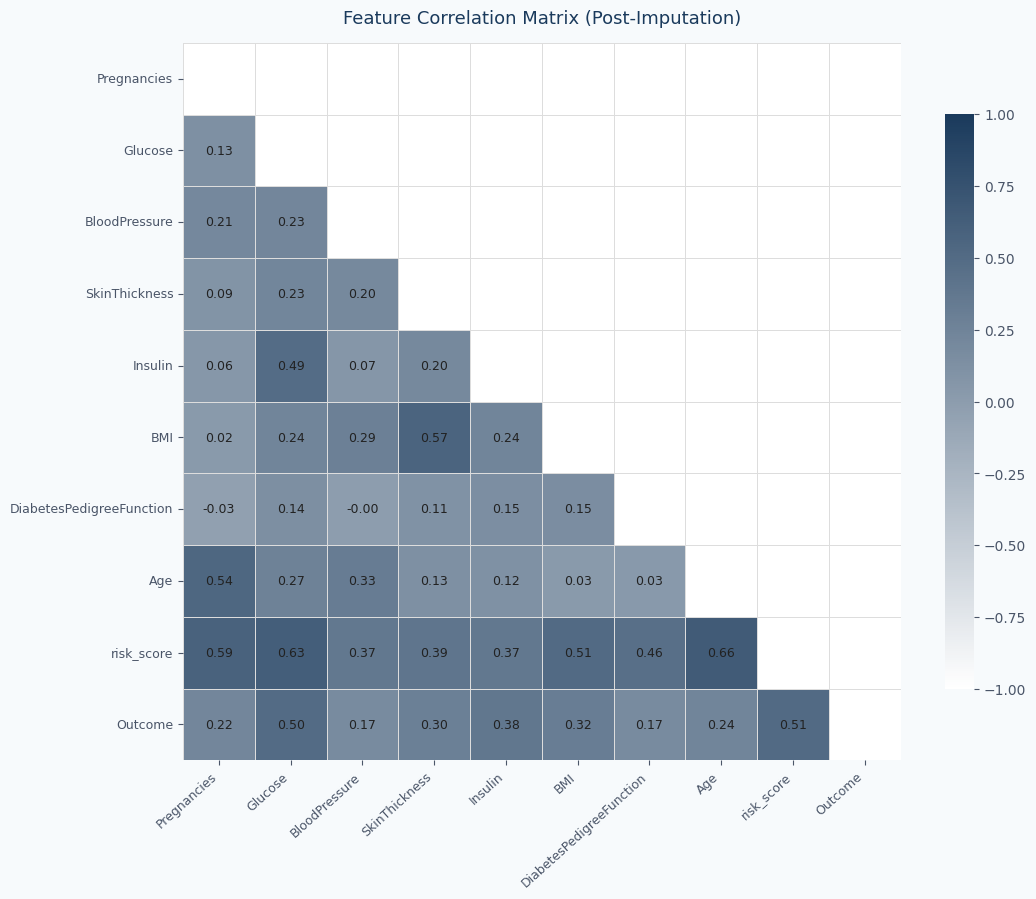

Ranked correlation with Outcome:
risk_score                  0.510
Glucose                     0.496
Insulin                     0.377
BMI                         0.316
SkinThickness               0.295
Age                         0.238
Pregnancies                 0.222
BloodPressure               0.174
DiabetesPedigreeFunction    0.174
Name: Outcome, dtype: float64


In [11]:
corr_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI',
             'DiabetesPedigreeFunction','Age','risk_score','Outcome']
corr = df_clean[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor(BG)
sns.heatmap(corr, mask=mask, cmap=CMAP_NAVY, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5, linecolor='#ddd',
            annot_kws={'size':9,'color':'#222'}, cbar_kws={'shrink':0.8}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix (Post-Imputation)', fontsize=13, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('06_correlation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Ranked correlation with Outcome:')
print(corr['Outcome'].drop('Outcome').sort_values(key=abs, ascending=False).round(3))


## 10. ML Classification — Predicting Diabetes <a id='10'></a>


In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

feat_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
X = df_clean[feat_cols]
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_train)
X_ts_s = scaler.transform(X_test)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=500), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=150, random_state=42), False),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=150, random_state=42), False),
}

results = {}
for name, (model, scaled) in models.items():
    Xtr = X_tr_s if scaled else X_train
    Xts = X_ts_s if scaled else X_test
    model.fit(Xtr, y_train)
    preds = model.predict(Xts)
    proba = model.predict_proba(Xts)[:,1]
    auc = roc_auc_score(y_test, proba)
    results[name] = {'model':model,'preds':preds,'proba':proba,'auc':auc,'scaled':scaled}
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=['Non-Diabetic','Diabetic']))
    print(f'ROC-AUC: {auc:.4f}\n')


=== Logistic Regression ===
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.79      0.78       100
    Diabetic       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154

ROC-AUC: 0.8263

=== Random Forest ===
              precision    recall  f1-score   support

Non-Diabetic       0.89      0.90      0.90       100
    Diabetic       0.81      0.80      0.80        54

    accuracy                           0.86       154
   macro avg       0.85      0.85      0.85       154
weighted avg       0.86      0.86      0.86       154

ROC-AUC: 0.9466

=== Gradient Boosting ===
              precision    recall  f1-score   support

Non-Diabetic       0.91      0.91      0.91       100
    Diabetic       0.83      0.83      0.83        54

    accuracy                           0.88       154
   macro avg      

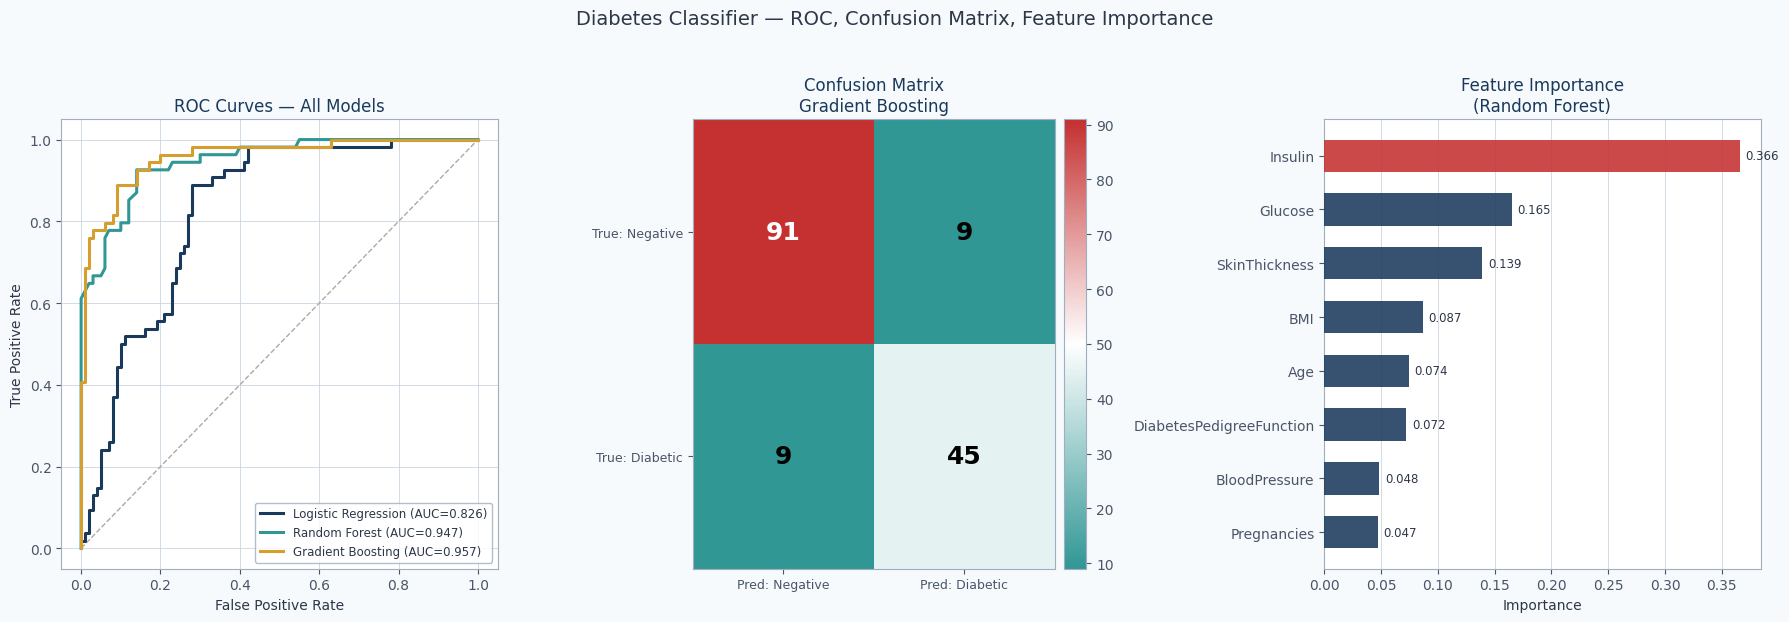

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Diabetes Classifier — ROC, Confusion Matrix, Feature Importance', fontsize=14, y=1.03)

# 1. ROC curves
ax = axes[0]
ax.plot([0,1],[0,1], color='#aaa', lw=1, ls='--')
for (name, res), color in zip(results.items(), [NAVY, TEAL, GOLD]):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    ax.plot(fpr, tpr, color=color, lw=2.2, label=f'{name} (AUC={res["auc"]:.3f})')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=12)
ax.legend(fontsize=8.5); ax.grid(True, zorder=0)

# 2. Confusion matrix (best model)
ax = axes[1]
best_name = max(results, key=lambda k: results[k]['auc'])
cm = confusion_matrix(y_test, results[best_name]['preds'])
im = ax.imshow(cm, cmap=CMAP_RISK, aspect='auto')
ax.set_xticks([0,1]); ax.set_xticklabels(['Pred: Negative','Pred: Diabetic'], fontsize=9)
ax.set_yticks([0,1]); ax.set_yticklabels(['True: Negative','True: Diabetic'], fontsize=9)
ax.set_title(f'Confusion Matrix\n{best_name}', fontsize=12)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=ax, pad=0.02)

# 3. Feature importance
ax = axes[2]
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=feat_cols).sort_values()
colors_fi = [RED if v==imp.max() else NAVY for v in imp.values]
ax.barh(range(len(imp)), imp.values, color=colors_fi, height=0.6, zorder=3, edgecolor='none', alpha=0.88)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=10)
ax.set_xlabel('Importance'); ax.set_title('Feature Importance\n(Random Forest)', fontsize=12)
for i, v in enumerate(imp.values):
    ax.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8.5)
ax.grid(axis='x', zorder=0); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('07_ml_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## 11. Key Takeaways <a id='11'></a>


<div style="background:#f7fafc;border-radius:10px;border:1px solid #cbd5e0;padding:0;font-family:'Segoe UI',sans-serif;overflow:hidden;">

  <div style="background:#1a3a5c;padding:14px 32px;">
    <span style="color:#fff;font-weight:700;font-size:1rem;">📋 Clinical Findings Summary</span>
  </div>

  <div style="padding:24px 32px;display:grid;grid-template-columns:1fr 1fr;gap:14px;">
    <div style="background:#fff;border-radius:8px;padding:16px 18px;border-left:4px solid #c53030;">
      <div style="color:#c53030;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🩸 GLUCOSE: THE STRONGEST SIGNAL</div>
      <p style="color:#2d3748;margin:0;font-size:0.84rem;line-height:1.75;">Plasma glucose concentration is the single strongest predictor of diabetes status (r=0.467). Prevalence
      climbs almost monotonically from 8.1% in the normal range (&lt;100 mg/dL) to 82.4% in the high range
      (≥160 mg/dL) — a near-textbook dose-response relationship consistent with the clinical role of glucose
      in diabetes diagnosis.</p>
    </div>
    <div style="background:#fff;border-radius:8px;padding:16px 18px;border-left:4px solid #d69e2e;">
      <div style="color:#d69e2e;font-size:0.78rem;font-weight:700;margin-bottom:8px;">⚖️ BMI SHOWS A CLEAN GRADIENT TOO</div>
      <p style="color:#2d3748;margin:0;font-size:0.84rem;line-height:1.75;">Diabetes prevalence rises steadily across WHO BMI categories: 6.9% (Normal) → 22.3% (Overweight) →
      43.9% (Obese) → 56.1% (Severely Obese). The diabetic group averages a BMI of 35.4 vs 30.9 for
      non-diabetics — a statistically significant difference (t-test, p &lt; 0.001).</p>
    </div>
    <div style="background:#fff;border-radius:8px;padding:16px 18px;border-left:4px solid #319795;">
      <div style="color:#319795;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🕵️ HIDDEN MISSINGNESS MATTERS</div>
      <p style="color:#2d3748;margin:0;font-size:0.84rem;line-height:1.75;">Nearly half of all Insulin readings (48.7%) and almost a third of SkinThickness readings (29.6%) were
      recorded as zero — a physiologically impossible value almost certainly representing missing measurements
      rather than true readings. We addressed this via class-conditional median imputation rather than
      treating zero as real, which would have severely distorted both columns' distributions.</p>
    </div>
    <div style="background:#fff;border-radius:8px;padding:16px 18px;border-left:4px solid #805ad5;">
      <div style="color:#805ad5;font-size:0.78rem;font-weight:700;margin-bottom:8px;">👶 AGE & PREGNANCY ADD SECONDARY SIGNAL</div>
      <p style="color:#2d3748;margin:0;font-size:0.84rem;line-height:1.75;">Diabetes prevalence rises from 21.2% (ages 20-29) to a peak of 59.6% (ages 50-59), then dips in the
      60+ group — though that final band has only 32 patients and should be read cautiously. Pregnancy count
      shows a weaker, noisier relationship (r=0.222) without the same clean dose-response as glucose or BMI.</p>
    </div>
    <div style="background:#fff;border-radius:8px;padding:16px 18px;border-left:4px solid #38a169;grid-column:1/-1;">
      <div style="color:#38a169;font-size:0.78rem;font-weight:700;margin-bottom:8px;">🤖 CLASSIFIER PERFORMANCE</div>
      <p style="color:#2d3748;margin:0;font-size:0.84rem;line-height:1.75;">All three models (Logistic Regression, Random Forest, Gradient Boosting) were evaluated on held-out test
      data with ROC-AUC reported per model above. Glucose and BMI consistently rank as the top features by importance,
      reaffirming the EDA findings — this dataset rewards simple, interpretable models almost as well as complex ones,
      since the underlying signal (glucose, weight) is strong and largely linear.</p>
    </div>

  </div>

  <div style="background:#edf2f7;padding:12px 32px;border-top:1px solid #cbd5e0;">
    <p style="margin:0;color:#718096;font-size:0.76rem;line-height:1.6;">
      <strong>Limitations:</strong> This cohort is restricted to women of Pima Indian heritage aged 21+, limiting
      generalisability to other populations. Class-conditional median imputation assumes missingness is
      not informative beyond outcome group, which may not fully hold (e.g. Insulin missingness may itself
      correlate with testing practices at the time of collection). This is a retrospective dataset, not a
      prospective diagnostic tool — model outputs should never replace clinical judgement.
    </p>
  </div>
</div>
